# Дополнительное задание 6
# Выполнил: Ибраев Дамир Беркутбаевич
# Вариант 2.1

## Задание 1

На данном этапе подключаются библиотеки, необходимые для загрузки, анализа, визуализации и предварительной обработки данных.
Также настраивается отображение таблиц и стиль графиков для более удобного анализа.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from math import ceil, log2
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

sns.set_theme(style="whitegrid")

Сначала импортирую данные из файла своего варианта.  
После загрузки полезно посмотреть размер таблицы, список признаков и первые строки, чтобы убедиться, что файл считан корректно.

In [16]:
file_path = "Вариант2_1.csv"

try:
    df = pd.read_csv(file_path)
    if df.shape[1] == 1:
        df = pd.read_csv(file_path, sep=';')
except:
    df = pd.read_csv(file_path, sep=';')

print("Размер таблицы:", df.shape)
display(df.head())
print("\nСтолбцы:")
print(df.columns.tolist())

Размер таблицы: (500, 17)


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Century Homes Realty Group LLC,House for sale,1790000,4,2.0,NaN,69-55 Kessel St,"Forest Hills, NY 11375","69-55 Kessel StForest Hills, NY 11375",United States,New York,Queens County,Queens,Kessel Street,"69-55 Kessel St, Flushing, NY 11375, USA",40.714321,-73.851440
1,Brokered by Best American Homes Inc,Multi-family home for sale,1175000,9,3.0,NaN,32-27 92nd St,"East Elmhurst, NY 11369","32-27 92nd StEast Elmhurst, NY 11369",United States,New York,Queens County,Queens,92nd Street,"32-27 92nd St, Flushing, NY 11369, USA",40.757913,-73.876076
2,Brokered by Douglas Elliman - Garden City,House for sale,579000,4,2.0,NaN,1523 Bayview Ave,"Bronx, NY 10465","1523 Bayview AveBronx, NY 10465",United States,New York,Bronx County,The Bronx,Bayview Avenue,"1523 Bayview Ave, Bronx, NY 10465, USA",40.845450,-73.817760
3,"Brokered by Robert E. Hill, Inc.",Co-op for sale,249000,1,1.0,850.0,601 Kappock St Apt 3N,"Bronx, NY 10463","601 Kappock St Apt 3NBronx, NY 10463",New York,Bronx County,The Bronx,Spuyten Duyvil,601,"601 Kappock St #3n, Bronx, NY 10463, USA",40.878977,-73.916004
4,Brokered by United Realty Associates,House for sale,2480000,3,2.0,3600.0,151-06 25th Ave,"Whitestone, NY 11357","151-06 25th AveWhitestone, NY 11357",United States,New York,Queens County,Queens,25th Avenue,"15106 25th Ave, Whitestone, NY 11357, USA",40.775458,-73.812549



Столбцы:
['BROKERTITLE', 'TYPE', 'PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'ADDRESS', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME', 'FORMATTED_ADDRESS', 'LATITUDE', 'LONGITUDE']


Нужно определить типы признаков и посмотреть, в каких столбцах есть пропуски.  
Это позволит выделить признаки, требующие отдельной обработки.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  500 non-null    object 
 1   TYPE                         500 non-null    object 
 2   PRICE                        500 non-null    int64  
 3   BEDS                         500 non-null    int64  
 4   BATH                         474 non-null    float64
 5   PROPERTYSQFT                 340 non-null    float64
 6   ADDRESS                      500 non-null    object 
 7   STATE                        500 non-null    object 
 8   MAIN_ADDRESS                 500 non-null    object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  500 non-null    object 
 10  LOCALITY                     471 non-null    object 
 11  SUBLOCALITY                  500 non-null    object 
 12  STREET_NAME                  500 non-null    object 
 13  LONG_NAME           

In [18]:
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "Количество пропусков": missing_count,
    "Процент пропусков": missing_percent,
    "Тип данных": df.dtypes.astype(str)
}).sort_values(by="Количество пропусков", ascending=False)

display(missing_table[missing_table["Количество пропусков"] > 0])

,Количество пропусков,Процент пропусков,Тип данных
PROPERTYSQFT,160,32.0,float64
LOCALITY,29,5.8,object
BATH,26,5.2,float64
LONGITUDE,14,2.8,float64
LATITUDE,14,2.8,float64


По таблице выше можно выделить признаки, в которых действительно присутствуют пропущенные значения.  
Для каждого такого признака важно определить:

- тип признака;
- долю пропусков;
- возможную причину их появления;
- разумную стратегию заполнения.

Далее исследование проводится отдельно по каждому признаку с пропусками.

In [19]:
missing_cols = missing_table[missing_table["Количество пропусков"] > 0].index.tolist()
missing_cols

['PROPERTYSQFT', 'LOCALITY', 'BATH', 'LONGITUDE', 'LATITUDE']

Ниже для каждого признака с пропусками я анализирую его связь с другими столбцами.  
Это нужно для того, чтобы понять, случайны ли пропуски, и можно ли восстановить значения, используя информацию из других признаков.

In [20]:
for col in missing_cols:
    print("=" * 80)
    print(f"Признак: {col}")
    print("Тип:", df[col].dtype)
    print("Количество пропусков:", df[col].isna().sum())
    print("Процент пропусков:", round(df[col].isna().mean() * 100, 2), "%")
    print("\nПримеры строк с пропусками:")
    display(df[df[col].isna()].head(10))

Признак: PROPERTYSQFT
Тип: float64
Количество пропусков: 160
Процент пропусков: 32.0 %

Примеры строк с пропусками:


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Century Homes Realty Group LLC,House for sale,1790000,4,2.0,NaN,69-55 Kessel St,"Forest Hills, NY 11375","69-55 Kessel StForest Hills, NY 11375",United States,New York,Queens County,Queens,Kessel Street,"69-55 Kessel St, Flushing, NY 11375, USA",40.714321,-73.851440
1,Brokered by Best American Homes Inc,Multi-family home for sale,1175000,9,3.0,NaN,32-27 92nd St,"East Elmhurst, NY 11369","32-27 92nd StEast Elmhurst, NY 11369",United States,New York,Queens County,Queens,92nd Street,"32-27 92nd St, Flushing, NY 11369, USA",40.757913,-73.876076
2,Brokered by Douglas Elliman - Garden City,House for sale,579000,4,2.0,NaN,1523 Bayview Ave,"Bronx, NY 10465","1523 Bayview AveBronx, NY 10465",United States,New York,Bronx County,The Bronx,Bayview Avenue,"1523 Bayview Ave, Bronx, NY 10465, USA",40.845450,-73.817760
7,Brokered by Keller Williams Rlty Landmark,Co-op for sale,305000,2,1.0,NaN,164-11 Willets Point Blvd Unit 2,"Whitestone, NY 11357","164-11 Willets Point Blvd Unit 2Whitestone, NY...",New York,NaN,Queens,Whitestone,164- 11,"164- 11 Willets Point Blvd #2, Whitestone, NY ...",40.783465,-73.799060
11,Brokered by Cross Country Realty,House for sale,428000,3,3.0,NaN,1126 E 73rd St Units 43 & 33,"Brooklyn, NY 11234","1126 E 73rd St Units 43 & 33Brooklyn, NY 11234",United States,New York,Kings County,Brooklyn,East 73rd Street,"1126 E 73rd St, Brooklyn, NY 11234, USA",40.627495,-73.915694
12,Brokered by Elegran Real Estate And Development,Co-op for sale,639000,1,1.0,NaN,45 E End Ave Apt 5E,"New York, NY 10028","45 E End Ave Apt 5ENew York, NY 10028",New York,NaN,New York,Manhattan,45,"45 East End Ave #5e, New York, NY 10028, USA",40.771720,-73.946705
13,Brokered by 5 Boro Realty Corp,House for sale,835000,3,2.0,NaN,4408 Flatlands Ave,"Brooklyn, NY 11234","4408 Flatlands AveBrooklyn, NY 11234",United States,New York,Kings County,Brooklyn,Flatlands Avenue,"4408 Flatlands Ave, Brooklyn, NY 11234, USA",40.622671,-73.932733
19,Brokered by Metro Net Realty Llc,House for sale,705000,2,2.0,NaN,76-22 57th Rd,"Middle Village, NY 11379","76-22 57th RdMiddle Village, NY 11379",United States,New York,Queens County,Queens,57th Road,"76-22 57th Rd, Flushing, NY 11379, USA",40.727192,-73.883684
20,Brokered by Sotheby's International Realty - D...,Co-op for sale,549000,1,1.0,NaN,535 E 72nd St Apt 4A,"New York, NY 10021","535 E 72nd St Apt 4ANew York, NY 10021",New York,New York County,New York,Manhattan,535,"535 E 72nd St #4a, New York, NY 10021, USA",40.766222,-73.951634
23,Brokered by Coldwell Banker American Homes,House for sale,599000,3,2.0,NaN,312F Beach 101st St,"Rockaway Park, NY 11694","312F Beach 101st StRockaway Park, NY 11694",United States,New York,Queens County,Queens,Beach 101st Street,"312F Beach 101st St, Rockaway Park, NY 11694, USA",40.585321,-73.822189


Признак: LOCALITY
Тип: object
Количество пропусков: 29
Процент пропусков: 5.8 %

Примеры строк с пропусками:


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
7,Brokered by Keller Williams Rlty Landmark,Co-op for sale,305000,2,1.0,NaN,164-11 Willets Point Blvd Unit 2,"Whitestone, NY 11357","164-11 Willets Point Blvd Unit 2Whitestone, NY...",New York,NaN,Queens,Whitestone,164- 11,"164- 11 Willets Point Blvd #2, Whitestone, NY ...",40.783465,-73.799060
12,Brokered by Elegran Real Estate And Development,Co-op for sale,639000,1,1.0,NaN,45 E End Ave Apt 5E,"New York, NY 10028","45 E End Ave Apt 5ENew York, NY 10028",New York,NaN,New York,Manhattan,45,"45 East End Ave #5e, New York, NY 10028, USA",40.771720,-73.946705
24,Brokered by Matias Real Estate,Townhouse for sale,334999,1,2.0,1059.0,306 Ilyssa Way,"Staten Island, NY 10312","306 Ilyssa WayStaten Island, NY 10312",United States,NaN,Richmond County,Staten Island,Ilyssa Way,"306 Ilyssa Way, Staten Island, NY 10312, USA",40.560143,-74.185436
36,Brokered by Genstone Properties,Multi-family home for sale,625000,5,NaN,NaN,198 Shepherd Ave,"Brooklyn, NY 11208","198 Shepherd AveBrooklyn, NY 11208",United States,NaN,Kings County,Brooklyn,Shepherd Avenue,"198 Shepherd Ave, Brooklyn, NY 11208, USA",40.679665,-73.881950
48,Brokered by Winzone Realty Inc,House for sale,3900000,5,6.0,7723.0,14446 Boulevard,"Malba, NY 11357","14446 BoulevardMalba, NY 11357",United States,NaN,Queens County,Queens,Boulevard,"144-46 Boulevard, Malba, NY 11357, USA",40.792422,-73.826076
57,Brokered by Homedax Real Estate Llc,Co-op for sale,350000,2,1.0,NaN,414 61st St Apt 4A,"Brooklyn, NY 11220","414 61st St Apt 4ABrooklyn, NY 11220",New York,NaN,Brooklyn,Sunset Park,414,"414 61st St #4a, Brooklyn, NY 11220, USA",40.639736,-74.018685
67,Brokered by Ubiq,Co-op for sale,310000,2,1.0,NaN,655 Riverside Dr Apt 5A,"New York, NY 10031","655 Riverside Dr Apt 5ANew York, NY 10031",New York,NaN,New York,Manhattan,655,"655 Riverside Dr #5a, New York, NY 10031, USA",40.825597,-73.952996
76,Brokered by Sowae Corp,Multi-family home for sale,499000,5,2.0,NaN,752 Rutland Rd,"Brooklyn, NY 11203","752 Rutland RdBrooklyn, NY 11203",United States,NaN,Kings County,Brooklyn,Rutland Road,"752 Rutland Rd, Brooklyn, NY 11203, USA",40.660140,-73.935489
92,Brokered by Keller Williams Realty Group,House for sale,575000,5,3.0,2076.0,627 E 236th St,"Bronx, NY 10466","627 E 236th StBronx, NY 10466",United States,NaN,Bronx County,The Bronx,East 236th Street,"627 E 236th St, Bronx, NY 10466, USA",40.896500,-73.858541
134,Brokered by EXIT REALTY TOP PROPERTIES,Multi-family home for sale,2800000,16,16.0,10720.0,1570 66th St,"Brooklyn, NY 11219","1570 66th StBrooklyn, NY 11219",United States,NaN,Kings County,Brooklyn,66th Street,"1570 66th St, Brooklyn, NY 11219, USA",40.621516,-73.996157


Признак: BATH
Тип: float64
Количество пропусков: 26
Процент пропусков: 5.2 %

Примеры строк с пропусками:


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
21,Brokered by Andrew Lichtenstein Inc,Multi-family home for sale,7200000,3,NaN,48000.0,3650 Bronx Blvd,"Bronx, NY 10467","3650 Bronx BlvdBronx, NY 10467",United States,New York,Bronx County,The Bronx,Bronx Boulevard,"3650 Bronx Blvd, Bronx, NY 10467, USA",40.881464,-73.867129
36,Brokered by Genstone Properties,Multi-family home for sale,625000,5,NaN,NaN,198 Shepherd Ave,"Brooklyn, NY 11208","198 Shepherd AveBrooklyn, NY 11208",United States,NaN,Kings County,Brooklyn,Shepherd Avenue,"198 Shepherd Ave, Brooklyn, NY 11208, USA",40.679665,-73.881950
44,Brokered by Momentum Real Estate Llc,House for sale,988000,4,NaN,2400.0,4 Minna St,"Staten Island, NY 10304","4 Minna StStaten Island, NY 10304",United States,New York,Richmond County,Staten Island,Minna Street,"4 Minna St, Staten Island, NY 10304, USA",40.594519,-74.090478
71,Brokered by COMPASS,Townhouse for sale,7400000,4,NaN,3700.0,413 Degraw St,"Brooklyn, NY 11217","413 Degraw StBrooklyn, NY 11217",United States,New York,Kings County,Brooklyn,Degraw Street,"413 Degraw St, Brooklyn, NY 11217, USA",40.682066,-73.990383
89,Brokered by BESMATCH REAL ESTATE,Multi-family home for sale,699000,3,NaN,2034.0,2728 Hone Ave,"Bronx, NY 10469","2728 Hone AveBronx, NY 10469",United States,New York,Bronx County,The Bronx,Hone Avenue,"2728 Hone Ave, Bronx, NY 10469, USA",40.866509,-73.857401
105,Brokered by RE MAX Edge,House for sale,850000,3,NaN,2160.0,167 Mills Ave,"Staten Island, NY 10305","167 Mills AveStaten Island, NY 10305",United States,New York,Richmond County,Staten Island,Mills Avenue,"167 Mills Ave, Staten Island, NY 10305, USA",40.593105,-74.066349
115,Brokered by COMPASS,Townhouse for sale,25000000,7,NaN,20000.0,11 Hubert St,"Manhattan, NY 10013","11 Hubert StManhattan, NY 10013",United States,New York,New York County,New York,Hubert Street,"11 Hubert St, New York, NY 10013, USA",40.721329,-74.009256
120,Brokered by COMPASS,Townhouse for sale,14600000,6,NaN,6630.0,122 W 73rd St,"Manhattan, NY 10023","122 W 73rd StManhattan, NY 10023",United States,New York,New York County,New York,West 73rd Street,"122 W 73rd St, New York, NY 10023, USA",40.778206,-73.979031
144,Brokered by RE MAX Real Estate Professionals,Multi-family home for sale,2999000,8,NaN,6000.0,7923 12th Ave,"Brooklyn, NY 11228","7923 12th AveBrooklyn, NY 11228",United States,New York,Kings County,Brooklyn,12th Avenue,"7923 12th Ave, Brooklyn, NY 11228, USA",40.618804,-74.012196
206,Brokered by Corcoran Westside Columbus,Townhouse for sale,23900000,6,NaN,7110.0,248 W 71st St,"New York, NY 10023","248 W 71st StNew York, NY 10023",United States,New York,New York County,New York,West 71st Street,"248 W 71st St, New York, NY 10023, USA",40.778544,-73.984091


Признак: LONGITUDE
Тип: float64
Количество пропусков: 14
Процент пропусков: 2.8 %

Примеры строк с пропусками:


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
39,Brokered by COMPASS,Co-op for sale,580000,1,1.0,NaN,305 W 55th St Apt 2A,"Manhattan, NY 10019","305 W 55th St Apt 2AManhattan, NY 10019",New York,New York County,New York,Manhattan,305,"305 W 55th St #2a, New York, NY 10019, USA",NaN,NaN
88,Brokered by Wonica REALTORS & Appraisers,Contingent,869900,4,2.0,2280.0,25 Copley St,"Staten Island, NY 10314","25 Copley StStaten Island, NY 10314",United States,New York,Richmond County,Staten Island,Copley Street,"25 Copley St, Staten Island, NY 10314, USA",NaN,NaN
123,Brokered by Winzone Realty Inc,Multi-family home for sale,1788000,6,5.0,NaN,136-08 Elder Ave,"Flushing, NY 11355","136-08 Elder AveFlushing, NY 11355",United States,New York,Queens County,Queens,Elder Avenue,"136-8 Elder Ave, Flushing, NY 11355, USA",NaN,NaN
124,Brokered by Home Global Realty,Multi-family home for sale,799000,4,3.0,1344.0,8519 Glenwood Rd,"Brooklyn, NY 11236","8519 Glenwood RdBrooklyn, NY 11236",United States,New York,Kings County,Brooklyn,Glenwood Road,"8519 Glenwood Rd, Brooklyn, NY 11236, USA",NaN,NaN
168,Brokered by Today Realty Corp.,House for sale,1200000,4,4.0,3300.0,2217 Gunther Ave,"Bronx, NY 10469","2217 Gunther AveBronx, NY 10469",United States,New York,Bronx County,The Bronx,Gunther Avenue,"2217 Gunther Ave, Bronx, NY 10469, USA",NaN,NaN
218,"Brokered by Robert E. Hill, Inc.",Co-op for sale,430000,2,2.0,1200.0,2727 Palisade Ave Apt 5B,"Bronx, NY 10463","2727 Palisade Ave Apt 5BBronx, NY 10463",New York,Bronx County,The Bronx,Spuyten Duyvil,2727,"2727 Palisade Ave #5b, Bronx, NY 10463, USA",NaN,NaN
306,Brokered by Exit All Seasons Realty,House for sale,611999,3,2.0,NaN,115-33 227th St,"Cambria Heights, NY 11411","115-33 227th StCambria Heights, NY 11411",United States,New York,Queens County,Queens,227th Street,"115-33 227th St, Cambria Heights, NY 11411, USA",NaN,NaN
328,Brokered by DiTommaso Real Estate,Contingent,785000,3,2.0,1950.0,148 Major Ave,"Staten Island, NY 10305","148 Major AveStaten Island, NY 10305",United States,New York,Richmond County,Staten Island,Major Avenue,"148 Major Ave, Staten Island, NY 10305, USA",NaN,NaN
349,Brokered by CENTURY 21 Galvez,Co-op for sale,340000,2,1.0,900.0,6035 Broadway Apt 6N,"Bronx, NY 10471","6035 Broadway Apt 6NBronx, NY 10471",New York,Bronx County,The Bronx,Fieldston,6035,"6035 Broadway #6b, Bronx, NY 10471, USA",NaN,NaN
364,Brokered by Real Broker Llc,Condo for sale,425000,2,2.0,800.0,3240 Netherland Ave Apt 6A,"Bronx, NY 10463","3240 Netherland Ave Apt 6ABronx, NY 10463",New York,Bronx County,The Bronx,Riverdale,3240,"3240 Netherland Ave #6a, Bronx, NY 10463, USA",NaN,NaN


Признак: LATITUDE
Тип: float64
Количество пропусков: 14
Процент пропусков: 2.8 %

Примеры строк с пропусками:


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
39,Brokered by COMPASS,Co-op for sale,580000,1,1.0,NaN,305 W 55th St Apt 2A,"Manhattan, NY 10019","305 W 55th St Apt 2AManhattan, NY 10019",New York,New York County,New York,Manhattan,305,"305 W 55th St #2a, New York, NY 10019, USA",NaN,NaN
88,Brokered by Wonica REALTORS & Appraisers,Contingent,869900,4,2.0,2280.0,25 Copley St,"Staten Island, NY 10314","25 Copley StStaten Island, NY 10314",United States,New York,Richmond County,Staten Island,Copley Street,"25 Copley St, Staten Island, NY 10314, USA",NaN,NaN
123,Brokered by Winzone Realty Inc,Multi-family home for sale,1788000,6,5.0,NaN,136-08 Elder Ave,"Flushing, NY 11355","136-08 Elder AveFlushing, NY 11355",United States,New York,Queens County,Queens,Elder Avenue,"136-8 Elder Ave, Flushing, NY 11355, USA",NaN,NaN
124,Brokered by Home Global Realty,Multi-family home for sale,799000,4,3.0,1344.0,8519 Glenwood Rd,"Brooklyn, NY 11236","8519 Glenwood RdBrooklyn, NY 11236",United States,New York,Kings County,Brooklyn,Glenwood Road,"8519 Glenwood Rd, Brooklyn, NY 11236, USA",NaN,NaN
168,Brokered by Today Realty Corp.,House for sale,1200000,4,4.0,3300.0,2217 Gunther Ave,"Bronx, NY 10469","2217 Gunther AveBronx, NY 10469",United States,New York,Bronx County,The Bronx,Gunther Avenue,"2217 Gunther Ave, Bronx, NY 10469, USA",NaN,NaN
218,"Brokered by Robert E. Hill, Inc.",Co-op for sale,430000,2,2.0,1200.0,2727 Palisade Ave Apt 5B,"Bronx, NY 10463","2727 Palisade Ave Apt 5BBronx, NY 10463",New York,Bronx County,The Bronx,Spuyten Duyvil,2727,"2727 Palisade Ave #5b, Bronx, NY 10463, USA",NaN,NaN
306,Brokered by Exit All Seasons Realty,House for sale,611999,3,2.0,NaN,115-33 227th St,"Cambria Heights, NY 11411","115-33 227th StCambria Heights, NY 11411",United States,New York,Queens County,Queens,227th Street,"115-33 227th St, Cambria Heights, NY 11411, USA",NaN,NaN
328,Brokered by DiTommaso Real Estate,Contingent,785000,3,2.0,1950.0,148 Major Ave,"Staten Island, NY 10305","148 Major AveStaten Island, NY 10305",United States,New York,Richmond County,Staten Island,Major Avenue,"148 Major Ave, Staten Island, NY 10305, USA",NaN,NaN
349,Brokered by CENTURY 21 Galvez,Co-op for sale,340000,2,1.0,900.0,6035 Broadway Apt 6N,"Bronx, NY 10471","6035 Broadway Apt 6NBronx, NY 10471",New York,Bronx County,The Bronx,Fieldston,6035,"6035 Broadway #6b, Bronx, NY 10471, USA",NaN,NaN
364,Brokered by Real Broker Llc,Condo for sale,425000,2,2.0,800.0,3240 Netherland Ave Apt 6A,"Bronx, NY 10463","3240 Netherland Ave Apt 6ABronx, NY 10463",New York,Bronx County,The Bronx,Riverdale,3240,"3240 Netherland Ave #6a, Bronx, NY 10463, USA",NaN,NaN


При анализе строк с пропущенными значениями можно заметить, что пропуски не всегда выглядят полностью случайными.  
В ряде случаев недостающие значения можно попытаться восстановить по другим столбцам:

- площадь дома (`PROPERTYSQFT`) может быть связана с числом спален и ванных комнат;
- локальность (`LOCALITY`) может восстанавливаться по адресу, административным признакам или повторяющимся объектам;
- число ванных комнат (`BATH`) может быть связано с площадью и количеством спален.

Поэтому в работе используется не только простое заполнение средним или модой, а более содержательная стратегия, учитывающая доступный контекст.

In [21]:
for col in missing_cols:
    print("=" * 80)
    print(f"Признак: {col}")
    if df[col].dtype == 'object':
        display(df[col].value_counts(dropna=False).head(20))
    else:
        display(df[col].describe())

Признак: PROPERTYSQFT


count      340.000000
mean      2491.179412
std       3489.366772
min        440.000000
25%       1064.750000
50%       1600.000000
75%       2418.000000
max      48000.000000
Name: PROPERTYSQFT, dtype: float64

Признак: LOCALITY


LOCALITY
New York           312
New York County     51
Queens County       49
NaN                 29
Bronx County        25
Kings County        24
Richmond County      5
United States        3
Brooklyn             1
Queens               1
Name: count, dtype: int64

Признак: BATH


count    474.000000
mean       2.641350
std        2.879184
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       50.000000
Name: BATH, dtype: float64

Признак: LONGITUDE


count    486.000000
mean     -73.939323
std        0.117345
min      -74.250510
25%      -73.993693
50%      -73.925626
75%      -73.856567
max      -73.713743
Name: LONGITUDE, dtype: float64

Признак: LATITUDE


count    486.000000
mean      40.714511
std        0.100475
min       40.502294
25%       40.623816
50%       40.727705
75%       40.782613
max       40.911070
Name: LATITUDE, dtype: float64

Выбранная стратегия:

### 1. LOCALITY
Это категориальный признак.  
Если удаётся определить значение по другим адресным данным, логично использовать их.  
Если точное восстановление невозможно, разумно заполнить пропуски наиболее частым значением (модой), поскольку это категориальный столбец.

### 2. BATH
Это количественный признак, но его распределение обычно несимметрично, а значения зависят от характеристик дома.  
Поэтому простое среднее может искажать данные.  
Более оправдано использовать медиану, желательно внутри близких по типу объектов групп. Если группировка не даёт результата, можно использовать общую медиану.

### 3. PROPERTYSQFT
Площадь — количественный признак, часто имеющий асимметричное распределение.  
Среднее значение здесь особенно чувствительно к выбросам, поэтому предпочтительнее использовать медиану.  
При наличии связи с количеством спален и ванных комнат можно использовать групповую медиану.

### 4. LATITUDE и LONGITUDE
По условию задания географические координаты не требуется обрабатывать, поэтому пропуски в этих признаках заполняться не будут.

In [22]:
df_clean = df.copy()

In [23]:
def fill_locality_from_group(data, group_col, target_col="LOCALITY"):
    if group_col in data.columns and target_col in data.columns:
        mode_map = (
            data.dropna(subset=[group_col, target_col])
            .groupby(group_col)[target_col]
            .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
        mask = data[target_col].isna() & data[group_col].notna()
        data.loc[mask, target_col] = data.loc[mask, group_col].map(mode_map)

for addr_col in ["ADDRESS", "FORMATTED_ADDRESS", "MAIN_ADDRESS"]:
    if addr_col in df_clean.columns and "LOCALITY" in df_clean.columns:
        fill_locality_from_group(df_clean, addr_col, "LOCALITY")

if "LOCALITY" in df_clean.columns:
    locality_mode = df_clean["LOCALITY"].mode().iloc[0]
    df_clean["LOCALITY"] = df_clean["LOCALITY"].fillna(locality_mode)

In [24]:
if "BATH" in df_clean.columns:
    if "BEDROOMS" in df_clean.columns:
        bath_group_median = df_clean.groupby("BEDROOMS")["BATH"].median()
        mask = df_clean["BATH"].isna() & df_clean["BEDROOMS"].notna()
        df_clean.loc[mask, "BATH"] = df_clean.loc[mask, "BEDROOMS"].map(bath_group_median)
    
    df_clean["BATH"] = df_clean["BATH"].fillna(df_clean["BATH"].median())

In [25]:
if "PROPERTYSQFT" in df_clean.columns:
    if {"BEDROOMS", "BATH"}.issubset(df_clean.columns):
        sqft_group = df_clean.groupby(["BEDROOMS", "BATH"])["PROPERTYSQFT"].median()
        mask = (
            df_clean["PROPERTYSQFT"].isna() &
            df_clean["BEDROOMS"].notna() &
            df_clean["BATH"].notna()
        )

        def fill_sqft(row):
            key = (row["BEDROOMS"], row["BATH"])
            return sqft_group.get(key, np.nan)

        df_clean.loc[mask, "PROPERTYSQFT"] = df_clean.loc[mask].apply(fill_sqft, axis=1)
    
    df_clean["PROPERTYSQFT"] = df_clean["PROPERTYSQFT"].fillna(df_clean["PROPERTYSQFT"].median())

После применения выбранной стратегии нужно убедиться, что пропуски были обработаны корректно.  
При этом координаты (`LATITUDE`, `LONGITUDE`) специально не заполняются, так как это прямо указано в задании.

In [26]:
result_missing = pd.DataFrame({
    "Пропуски после обработки": df_clean.isna().sum(),
    "Процент после обработки": (df_clean.isna().mean() * 100).round(2)
}).sort_values(by="Пропуски после обработки", ascending=False)

display(result_missing[result_missing["Пропуски после обработки"] > 0])

,Пропуски после обработки,Процент после обработки
LONGITUDE,14,2.8
LATITUDE,14,2.8


После заполнения пропусков в содержательных признаках можно сделать вывод, что выбранная стратегия является более обоснованной, чем механическое заполнение средним значением по столбцу.

Для категориального признака использовано восстановление по связанным адресным данным и, при необходимости, заполнение модой.  
Для количественных признаков использована медиана, в том числе внутри групп, что лучше сохраняет устойчивость к выбросам и уменьшает риск искажения распределения.

Координаты не обрабатывались, поскольку по условию задания это не требуется.

Теперь нужно проверить, как выглядят распределения количественных признаков после обработки.  
Для непрерывных признаков число интервалов гистограммы выбирается по правилу Стёрджеса

Для признака `PROPERTYSQFT` дополнительно анализируются логарифмированные значения, так как этот признак обычно имеет сильную правостороннюю асимметрию.

In [28]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols

['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']

In [29]:
def sturges_bins(series):
    n = series.dropna().shape[0]
    return ceil(1 + log2(n)) if n > 1 else 1

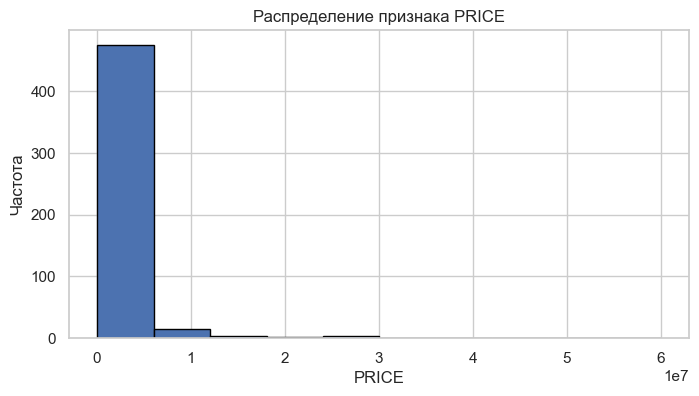

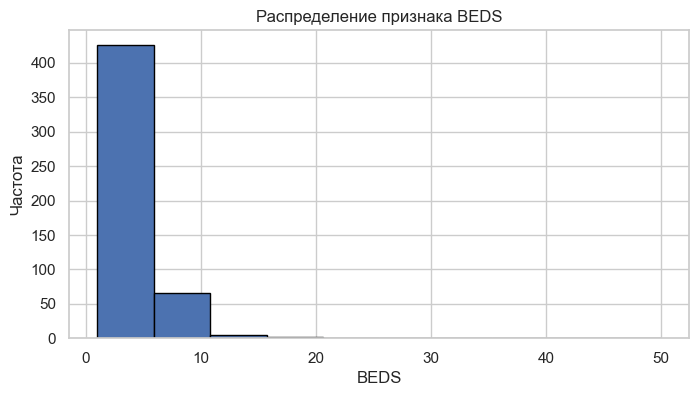

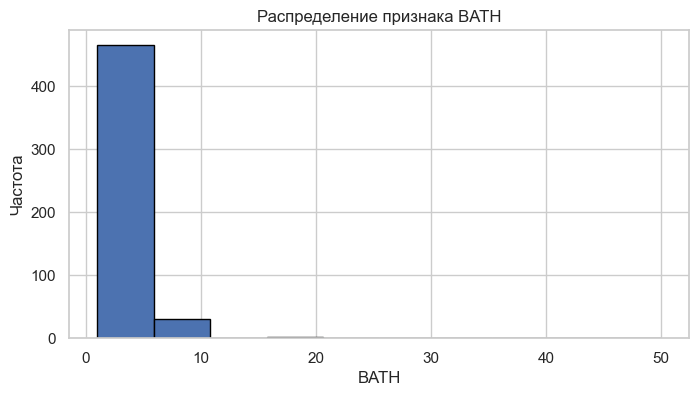

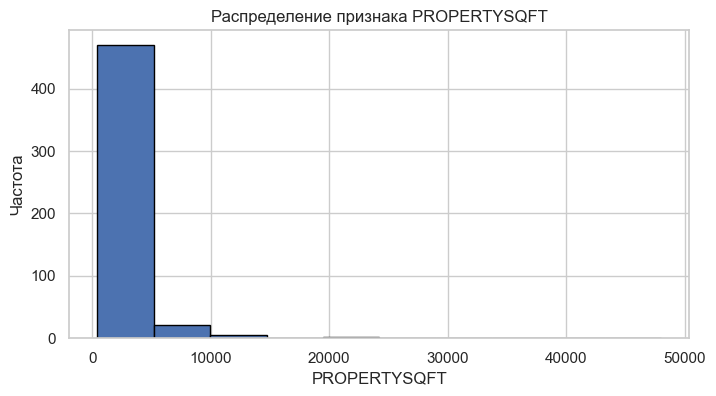

In [30]:
for col in numeric_cols:
    if col in ["LATITUDE", "LONGITUDE"]:
        continue
    
    plt.figure(figsize=(8, 4))
    bins = sturges_bins(df_clean[col])
    plt.hist(df_clean[col].dropna(), bins=bins, edgecolor='black')
    plt.title(f"Распределение признака {col}")
    plt.xlabel(col)
    plt.ylabel("Частота")
    plt.show()

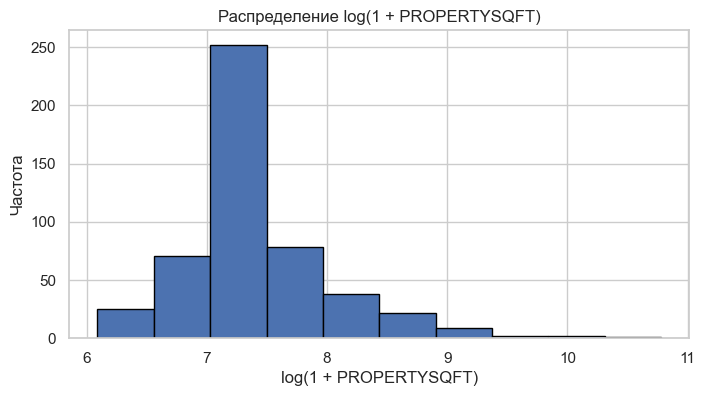

In [35]:
if "PROPERTYSQFT" in df_clean.columns:
    plt.figure(figsize=(8, 4))
    log_sqft = np.log1p(df_clean["PROPERTYSQFT"].dropna())
    bins = sturges_bins(log_sqft)
    plt.hist(log_sqft, bins=bins, edgecolor='black')
    plt.title("Распределение log(1 + PROPERTYSQFT)")
    plt.xlabel("log(1 + PROPERTYSQFT)")
    plt.ylabel("Частота")
    plt.show()

После заполнения пропусков основные формы распределений количественных признаков в целом сохраняются.  
Это позволяет сделать вывод, что выбранная стратегия не вносит грубых искажений в данные.

Для площади дома более информативным оказывается анализ логарифмированных значений, поскольку логарифмирование уменьшает влияние крупных выбросов и делает распределение более наглядным для сравнения.

# Задание 2

По условию задания из набора данных нужно удалить следующие столбцы:

- `ADDRESS`
- `STATE`
- `MAIN_ADDRESS`
- `LONG_NAME`
- `FORMATTED_ADDRESS`
- `LATITUDE`
- `LONGITUDE`

Также отдельно удаляется целевой признак `PRICE`, так как он не должен входить в набор входных признаков.

In [36]:
drop_cols = [
    "ADDRESS",
    "STATE",
    "MAIN_ADDRESS",
    "LONG_NAME",
    "FORMATTED_ADDRESS",
    "LATITUDE",
    "LONGITUDE"
]

existing_drop_cols = [col for col in drop_cols if col in df_clean.columns]
df_model = df_clean.drop(columns=existing_drop_cols, errors="ignore")

target_col = "PRICE"
y = df_model[target_col].copy() if target_col in df_model.columns else None
X = df_model.drop(columns=[target_col], errors="ignore")

print("Размер X:", X.shape)
print("Размер y:", None if y is None else y.shape)
display(X.head())

Размер X: (500, 9)
Размер y: (500,)


,BROKERTITLE,TYPE,BEDS,BATH,PROPERTYSQFT,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME
0,Brokered by Century Homes Realty Group LLC,House for sale,4,2.0,1600.0,United States,New York,Queens County,Queens
1,Brokered by Best American Homes Inc,Multi-family home for sale,9,3.0,1600.0,United States,New York,Queens County,Queens
2,Brokered by Douglas Elliman - Garden City,House for sale,4,2.0,1600.0,United States,New York,Bronx County,The Bronx
3,"Brokered by Robert E. Hill, Inc.",Co-op for sale,1,1.0,850.0,New York,Bronx County,The Bronx,Spuyten Duyvil
4,Brokered by United Realty Associates,House for sale,3,2.0,3600.0,United States,New York,Queens County,Queens


Перед подготовкой данных к моделированию нужно разделить признаки по типам:

- количественные;
- категориальные.

Это необходимо потому, что для них будут применяться разные методы преобразования.

In [38]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Количественные признаки:")
print(numeric_features)

print("\nКатегориальные признаки:")
print(categorical_features)

Количественные признаки:
['BEDS', 'BATH', 'PROPERTYSQFT']

Категориальные признаки:
['BROKERTITLE', 'TYPE', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'SUBLOCALITY', 'STREET_NAME']


Количественные признаки

Для количественных признаков целесообразно использовать масштабирование, так как признаки могут измеряться в разных единицах и иметь разные диапазоны значений.

В данной работе применяется `StandardScaler`, поскольку:
- он приводит признаки к сопоставимому масштабу;
- хорошо подходит для многих алгоритмов машинного обучения;
- удобен, если признаки имеют разный разброс.

Если бы некоторый признак имел строго ограниченный диапазон и не содержал существенных выбросов, можно было бы рассмотреть `MinMaxScaler`.  
Однако в общем случае стандартизация выглядит более универсальным решением.

Категориальные признаки

Для категориальных признаков используется `OneHotEncoder`, поскольку:
- между категориями нет естественного числового порядка;
- простая замена категорий числами могла бы создать ложное отношение порядка;
- one-hot кодирование является стандартным и интерпретируемым способом преобразования номинативных признаков.

In [39]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [44]:
X_prepared = preprocessor.fit_transform(X)

cat_feature_names = []
if len(categorical_features) > 0:
    encoder = preprocessor.named_transformers_["cat"].named_steps["encoder"]
    cat_feature_names = encoder.get_feature_names_out(categorical_features).tolist()

final_feature_names = numeric_features + cat_feature_names

X_prepared_df = pd.DataFrame(X_prepared, columns=final_feature_names)

print("Размер итогового набора признаков:", X_prepared_df.shape)
display(X_prepared_df.head())

Размер итогового набора признаков: (500, 363)


,BEDS,BATH,PROPERTYSQFT,BROKERTITLE_Brokered by 5 Boro Realty Corp,BROKERTITLE_Brokered by Acadia Real Estate Grp LLC,BROKERTITLE_Brokered by Agency Real Estate Services Llc,BROKERTITLE_Brokered by Alexiou Realty,BROKERTITLE_Brokered by All Going Realty Llc,BROKERTITLE_Brokered by American Homes Group,BROKERTITLE_Brokered by Andrew Lichtenstein Inc,BROKERTITLE_Brokered by Ardebili Michael,BROKERTITLE_Brokered by Ashford Homes LLC,BROKERTITLE_Brokered by Asimina Perikleous,BROKERTITLE_Brokered by Avenues - Headquarters,BROKERTITLE_Brokered by B Square Realty,"BROKERTITLE_Brokered by BEN BAY REALTY CO OF BAY RIDGE, LLC",BROKERTITLE_Brokered by BERGEN BASIN REALTY,BROKERTITLE_Brokered by BESMATCH REAL ESTATE,BROKERTITLE_Brokered by BHHS Fillmore R.E.,BROKERTITLE_Brokered by BLACKWATER ASSOCIATES INC,BROKERTITLE_Brokered by BROOKLYN`S 4 U REALTY,BROKERTITLE_Brokered by BRPI - Brooklyn Real Property,BROKERTITLE_Brokered by Belle Harbor Realty,BROKERTITLE_Brokered by Ben Bay Realty Company of Staten Island LLC,BROKERTITLE_Brokered by Benjamin Realty Since 1980,BROKERTITLE_Brokered by Berkshire Hathaway,BROKERTITLE_Brokered by Best American Homes Inc,BROKERTITLE_Brokered by Better Homes and Gardens Real Estate Safari Realty,BROKERTITLE_Brokered by Bhuiyan Properties LLC,BROKERTITLE_Brokered by Blue Key Real Estate Brokerage,BROKERTITLE_Brokered by Blue Sky Realty Group LLC,BROKERTITLE_Brokered by Bond New York- Columbus Circle,BROKERTITLE_Brokered by Bright Horizons Realty Inc,"BROKERTITLE_Brokered by Brooklyn Real Property, Inc",BROKERTITLE_Brokered by Brown Harris Stevens,BROKERTITLE_Brokered by Brown Harris Stevens - 129 Montague Street,BROKERTITLE_Brokered by Brown Harris Stevens - 1926 Broadway,BROKERTITLE_Brokered by Brown Harris Stevens- 3531 Johnson Avenue,BROKERTITLE_Brokered by Budget Real Estate Nyc Inc,BROKERTITLE_Brokered by CENTURY 21 Future Homes Realty,BROKERTITLE_Brokered by CENTURY 21 Galvez,BROKERTITLE_Brokered by CENTURY 21 Homefront,BROKERTITLE_Brokered by CENTURY 21 MK Realty,BROKERTITLE_Brokered by CENTURY 21 Marciano,BROKERTITLE_Brokered by CHRISTIE'S INT.REAL ESTATE GROUP,BROKERTITLE_Brokered by COMPASS,BROKERTITLE_Brokered by COMPASS REALTY CENTRAL INC,"BROKERTITLE_Brokered by Century 21 Amiable Realty Group II, Inc.",BROKERTITLE_Brokered by Century 21 Awaye Realty,BROKERTITLE_Brokered by Century 21 Realty First,BROKERTITLE_Brokered by Century Homes Realty Group LLC,BROKERTITLE_Brokered by Charles Rutenberg Realty Inc,BROKERTITLE_Brokered by Chase Global Realty Corp,BROKERTITLE_Brokered by Cohen And Cohen Consulting,BROKERTITLE_Brokered by Coldwell Banker Advantage,BROKERTITLE_Brokered by Coldwell Banker American Homes,BROKERTITLE_Brokered by Coldwell Banker Kueber Realty,BROKERTITLE_Brokered by Coldwell Banker M&D Good Life,BROKERTITLE_Brokered by Coldwell Banker Warburg,BROKERTITLE_Brokered by Comfort Homes Realty Group,"BROKERTITLE_Brokered by Compass Greater New York, LLC",BROKERTITLE_Brokered by Corcoran Brooklyn Heights,BROKERTITLE_Brokered by Corcoran Chelsea/Flatiron,BROKERTITLE_Brokered by Corcoran East Side,BROKERTITLE_Brokered by Corcoran Long Island City,BROKERTITLE_Brokered by Corcoran Park Slope,BROKERTITLE_Brokered by Corcoran SoHo,BROKERTITLE_Brokered by Corcoran West Side,BROKERTITLE_Brokered by Corcoran West Side Gallery,BROKERTITLE_Brokered by Corcoran Westside Columbus,BROKERTITLE_Brokered by Corcoran Williamsburg Bedford,BROKERTITLE_Brokered by Cross Country Realty,BROKERTITLE_Brokered by Cypress Estates Realty LLC,BROKERTITLE_Brokered by DEBTFREESOLUTIONS LLC,BROKERTITLE_Brokered by Daniel Gale Sotheby's International Realty,BROKERTITLE_Brokered by De Luca Realty Group INC,BROKERTITLE_Brokered by DiTommaso Real Estate,BROKERTITLE_Brokered by Diamond Real Inc,BROKERTITLE_Brokered by Direct Access Real Estate Inc,BROKERTITLE_Brokered by Ditommaso Real Estate,BROKERTITLE_Brokered by Douglas Elliman -111 Fifth Ave,BROKERTITLE_Brokered by Douglas Elliman - 140 Franklin,BROKERTITLE_Brokered b

В результате подготовки данных был сформирован общий набор признаков, который состоит из:

- масштабированных количественных признаков;
- закодированных категориальных признаков.

Такой формат данных уже можно передавать на вход модели машинного обучения для прогнозирования цены дома.

In [43]:
X_prepared_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Columns: 363 entries, BEDS to STREET_NAME_Woodside
dtypes: float64(363)
memory usage: 1.4 MB


# Вывод

В ходе выполнения работы были загружены и исследованы данные о продажах домов.  
Для признаков с пропущенными значениями был проведён анализ, определены их типы, рассчитана доля пропусков и выбрана стратегия заполнения, основанная не только на формальных статистиках, но и на содержательной связи признаков между собой.

После обработки пропусков были проанализированы распределения количественных признаков.  
Это позволило убедиться, что выбранная стратегия не приводит к грубому искажению структуры данных.

На втором этапе были удалены признаки, не предназначенные для моделирования, выполнено масштабирование количественных признаков и one-hot кодирование категориальных признаков.  
В итоге был сформирован итоговый набор входных признаков, пригодный для последующего построения модели прогнозирования цены дома.